# Task 6 - Advanced Visualisations
**Dataset:** Cleaned Telco Customer Churn  
In this task, multiple visualization techniques were used to analyze the cleaned Telco Customer Churn dataset.

Different chart types were applied to examine various relationships and distributions within the data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('cleaned_churn_data.csv')
print("Loaded:", df.shape)

# add tenure segments for grouped analysis
df['Tenure_Segment'] = pd.cut(df['tenure'], bins=[0,12,36,72],
    labels=['New (0-12m)', 'Mid-term (13-36m)', 'Long-term (37+m)'], include_lowest=True)

print("Ready for visualisations")

Loaded: (7043, 21)
Ready for visualisations


## Chart 1: Box Plots - Charges by Churn Status
This visualization compares monthly charges across churn categories using box plots.

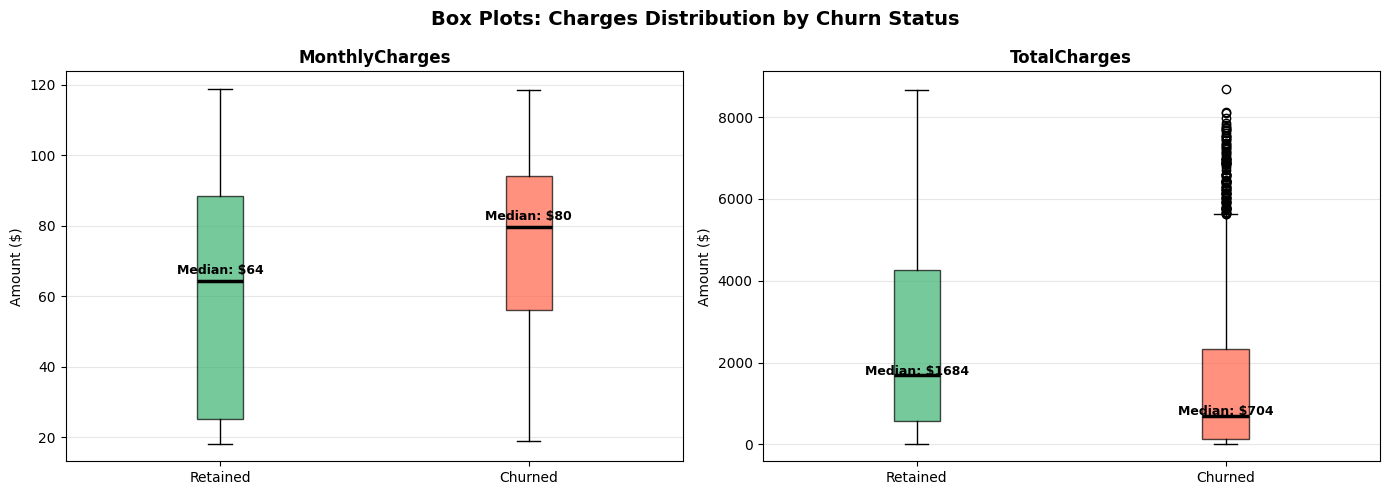

Key insight: Churned customers pay HIGHER monthly charges but have LOWER total charges (they leave earlier)


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Box Plots: Charges Distribution by Churn Status', fontsize=14, fontweight='bold')

for ax, col in zip(axes, ['MonthlyCharges', 'TotalCharges']):
    data_retained = df[df['Churn']==0][col].dropna()
    data_churned  = df[df['Churn']==1][col].dropna()
    bp = ax.boxplot([data_retained, data_churned], labels=['Retained', 'Churned'],
                    patch_artist=True, notch=False,
                    medianprops={'color':'black','linewidth':2.5})
    colors_bp = ['mediumseagreen', 'tomato']  # tried different colors first, liked these
    for patch, color in zip(bp['boxes'], colors_bp):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    for median in bp['medians']:
        median.set_color('black')
    ax.set_title(col, fontweight='bold')
    ax.set_ylabel('Amount ($)')
    ax.grid(axis='y', alpha=0.3)
    for i, (grp, label) in enumerate(zip([data_retained, data_churned], ['Retained','Churned']), 1):
        ax.text(i, grp.median()+2, f'Median: ${grp.median():.0f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('viz_01_boxplots.png', bbox_inches='tight', dpi=120)
plt.show()
print("Key insight: Churned customers pay HIGHER monthly charges but have LOWER total charges (they leave earlier)")

## Chart 2: Box Plots - Monthly Charges by Contract Type
This visualization compares monthly charges across different contract types using box plots.

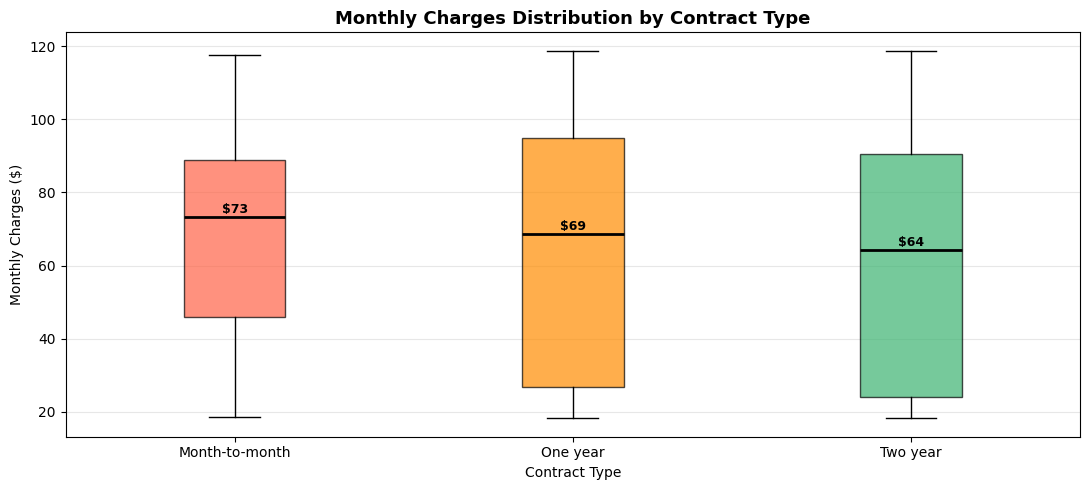

In [3]:
fig, ax = plt.subplots(figsize=(11, 5))
contracts = df['Contract'].unique()
data_by_contract = [df[df['Contract']==c]['MonthlyCharges'] for c in contracts]

bp = ax.boxplot(data_by_contract, labels=contracts, patch_artist=True)
palette = ['tomato', 'darkorange', 'mediumseagreen']
for patch, color in zip(bp['boxes'], palette):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
for median in bp['medians']:
    median.set_color('black')
    median.set_linewidth(2)

ax.set_title('Monthly Charges Distribution by Contract Type', fontsize=13, fontweight='bold')
ax.set_ylabel('Monthly Charges ($)')
ax.grid(axis='y', alpha=0.3)
ax.set_xlabel('Contract Type')

for i, c in enumerate(contracts, 1):
    med = df[df['Contract']==c]['MonthlyCharges'].median()
    ax.text(i, med+1, f'${med:.0f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('viz_02_boxplots_contract.png', bbox_inches='tight', dpi=120)
plt.show()

## Chart 3: Violin Plots - Tenure by Churn
This visualization examines the distribution of tenure across churn categories using violin plots.

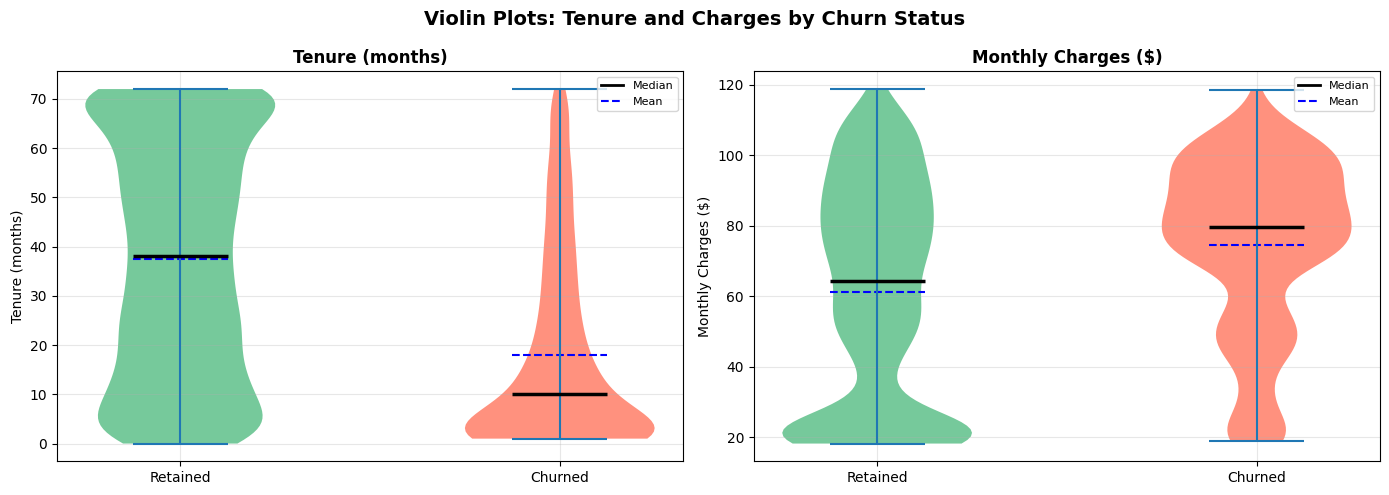

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Violin Plots: Tenure and Charges by Churn Status', fontsize=14, fontweight='bold')

for ax, col, title in zip(axes, ['tenure', 'MonthlyCharges'], ['Tenure (months)', 'Monthly Charges ($)']):
    parts = ax.violinplot(
        [df[df['Churn']==0][col].dropna(), df[df['Churn']==1][col].dropna()],
        showmedians=True, showmeans=True, showextrema=True
    )
    colors_v = ['mediumseagreen', 'tomato']
    for pc, color in zip(parts['bodies'], colors_v):
        pc.set_facecolor(color)
        pc.set_alpha(0.7)
    parts['cmedians'].set_color('black')
    parts['cmedians'].set_linewidth(2.5)
    parts['cmeans'].set_color('blue')
    parts['cmeans'].set_linewidth(1.5)
    parts['cmeans'].set_linestyle('--')
    ax.set_xticks([1, 2])
    ax.set_xticklabels(['Retained', 'Churned'])
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel(title)
    ax.grid(alpha=0.3)
    ax.legend([plt.Line2D([0],[0],color='black',lw=2),
               plt.Line2D([0],[0],color='blue',lw=1.5,linestyle='--')],
              ['Median','Mean'], fontsize=8)

plt.tight_layout()
plt.savefig('viz_03_violinplots.png', bbox_inches='tight', dpi=120)
plt.show()

## Chart 4: Grouped Violin Plot - Charges by Contract × Churn
This visualization compares monthly charges across contract types and churn categories using grouped violin plots.

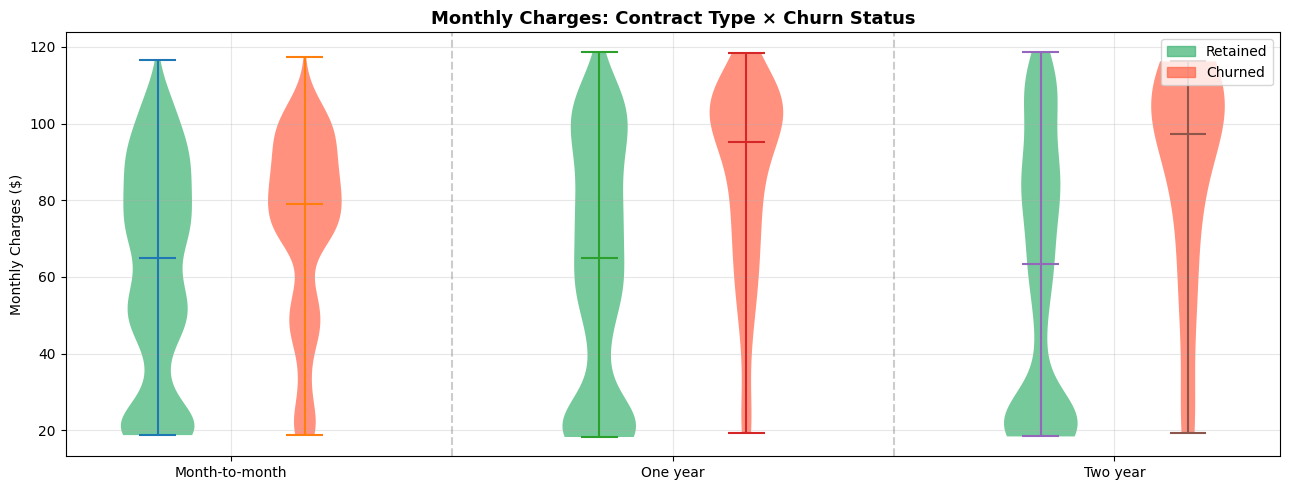

In [5]:
fig, ax = plt.subplots(figsize=(13, 5))

contracts_list = ['Month-to-month', 'One year', 'Two year']
positions_retained = [1, 4, 7]
positions_churned  = [2, 5, 8]
colors_grouped = ['mediumseagreen', 'tomato']
labels_added = set()

for contract, pos_r, pos_c in zip(contracts_list, positions_retained, positions_churned):
    for churn_val, pos, color, lbl in [(0, pos_r, 'mediumseagreen', 'Retained'), (1, pos_c, 'tomato', 'Churned')]:
        data = df[(df['Contract']==contract) & (df['Churn']==churn_val)]['MonthlyCharges'].dropna()
        if len(data) > 5:
            parts = ax.violinplot([data], positions=[pos], showmedians=True)
            for pc in parts['bodies']:
                pc.set_facecolor(color)
                pc.set_alpha(0.7)

ax.set_xticks([1.5, 4.5, 7.5])
ax.set_xticklabels(contracts_list)
ax.set_title('Monthly Charges: Contract Type × Churn Status', fontsize=13, fontweight='bold')
ax.set_ylabel('Monthly Charges ($)')
ax.grid(alpha=0.3)
ax.axvline(3, color='gray', linestyle='--', alpha=0.4)
ax.axvline(6, color='gray', linestyle='--', alpha=0.4)
handles = [plt.Rectangle((0,0),1,1,color='mediumseagreen',alpha=0.7),
           plt.Rectangle((0,0),1,1,color='tomato',alpha=0.7)]
ax.legend(handles, ['Retained','Churned'], fontsize=10)

plt.tight_layout()
plt.savefig('viz_04_violin_grouped.png', bbox_inches='tight', dpi=120)
plt.show()

## Chart 5: Pair Plot
A pair plot was generated to examine relationships among numerical variables.

Data points were colored by churn status to observe potential separation patterns.

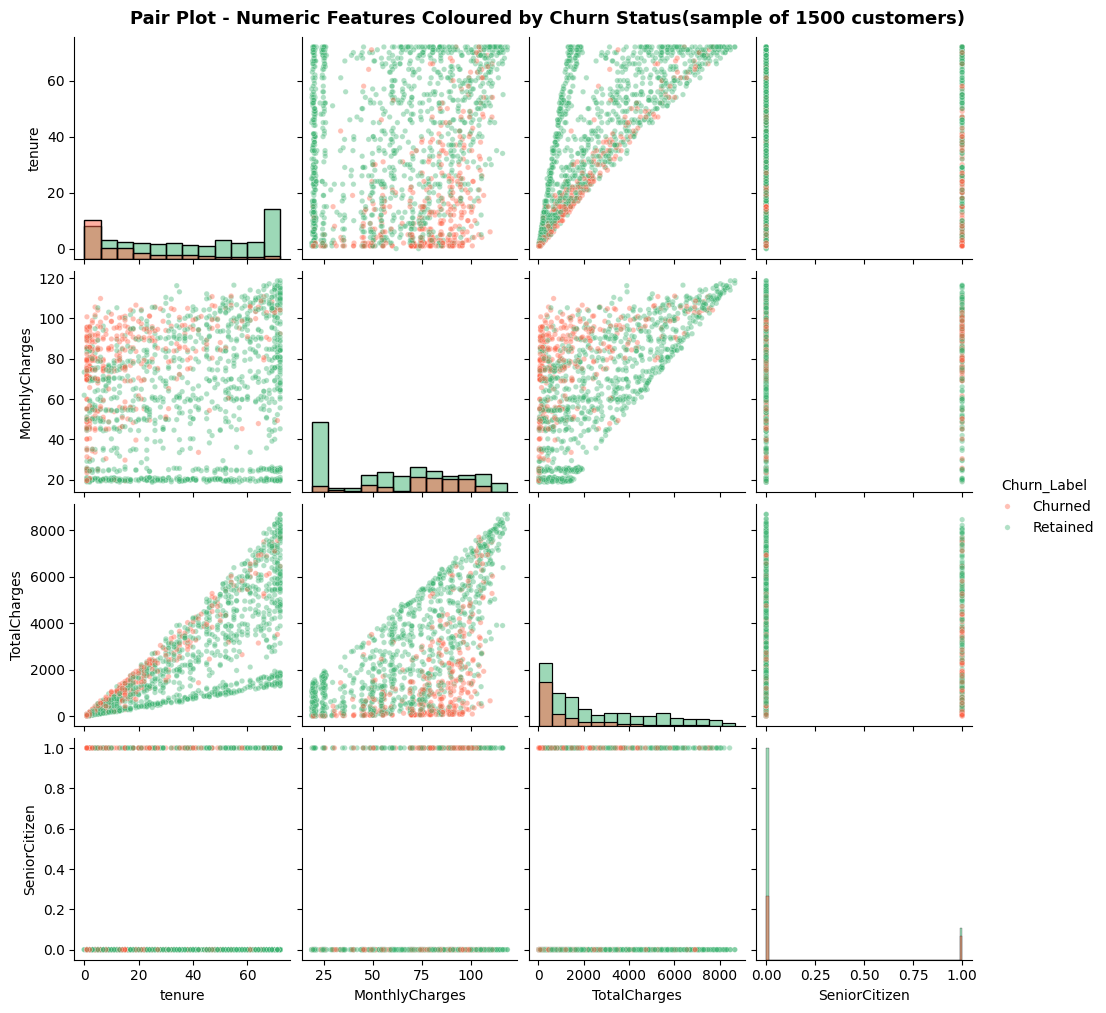

Each scatter = one pair of variables. Separated clusters = those variables can distinguish churners.


In [6]:
# using a sample to keep it fast - pair plots on 7000 rows can be slow
sample = df[['tenure','MonthlyCharges','TotalCharges','SeniorCitizen','Churn']].copy()
sample['Churn_Label'] = sample['Churn'].map({0:'Retained', 1:'Churned'})
my_sample = sample.sample(1500, random_state=42)  # sample for speed

g = sns.pairplot(
    my_sample.drop(columns=['Churn']),
    hue='Churn_Label',
    palette={'Retained':'mediumseagreen', 'Churned':'tomato'},
    plot_kws={'alpha':0.4, 's':15},
    diag_kind='hist'
)
g.fig.suptitle('Pair Plot - Numeric Features Coloured by Churn Status(sample of 1500 customers)', 
               y=1.01, fontsize=13, fontweight='bold')
plt.savefig('viz_05_pairplot.png', bbox_inches='tight', dpi=100)
plt.show()
print("Each scatter = one pair of variables. Separated clusters = those variables can distinguish churners.")

## Chart 6: Heatmaps
Heatmaps were generated to visualize relationships within the dataset.

Two heatmaps were created:
- A correlation heatmap for numerical variables
- A churn rate heatmap across selected service combinations

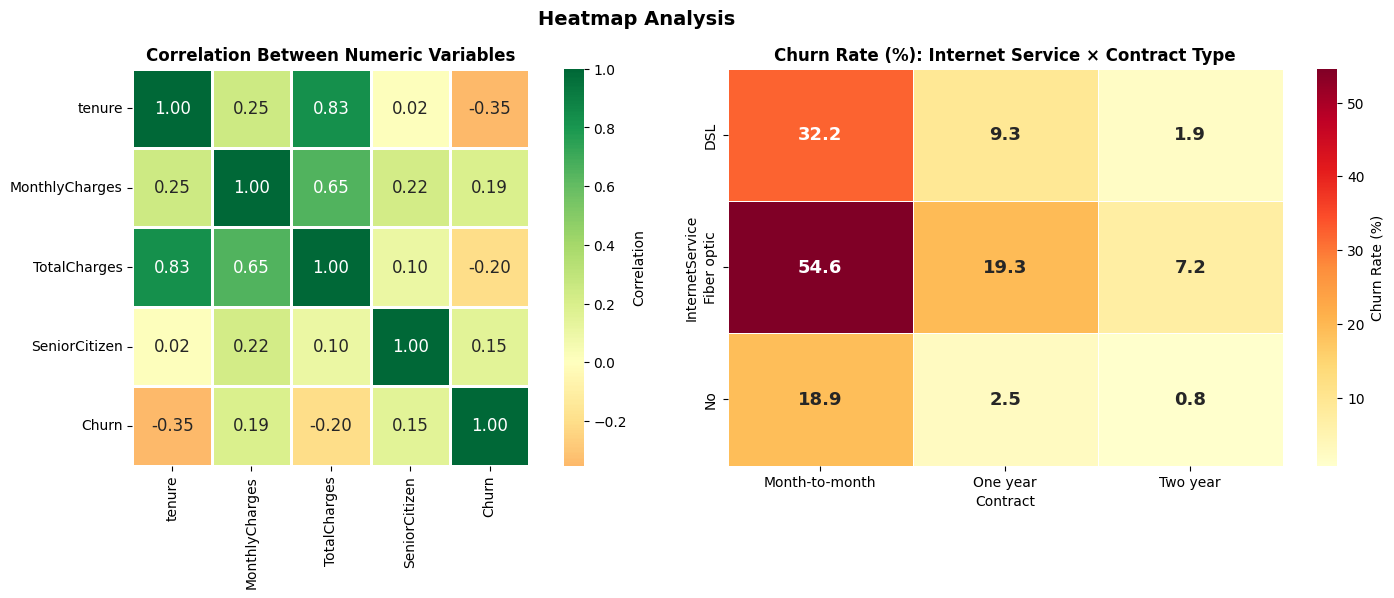

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Heatmap Analysis', fontsize=14, fontweight='bold')

# correlation heatmap
numeric_cols = ['tenure','MonthlyCharges','TotalCharges','SeniorCitizen','Churn']
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            square=True, linewidths=0.8, annot_kws={'size':12},
            ax=axes[0], cbar_kws={'label':'Correlation'})
axes[0].set_title('Correlation Between Numeric Variables', fontweight='bold')

# churn rate heatmap: internet service x contract type
pivot2 = df.pivot_table(values='Churn', index='InternetService',
                         columns='Contract', aggfunc='mean') * 100
sns.heatmap(pivot2, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, annot_kws={'size':13, 'weight':'bold'},
            ax=axes[1], cbar_kws={'label':'Churn Rate (%)'})
axes[1].set_title('Churn Rate (%): Internet Service × Contract Type', fontweight='bold')

plt.tight_layout()
plt.savefig('viz_06_heatmaps.png', bbox_inches='tight', dpi=120)
plt.show()

## Chart 7: KDE Plots (Kernel Density Estimation)
KDE plots were used to examine the distribution of selected continuous variables across churn categories.

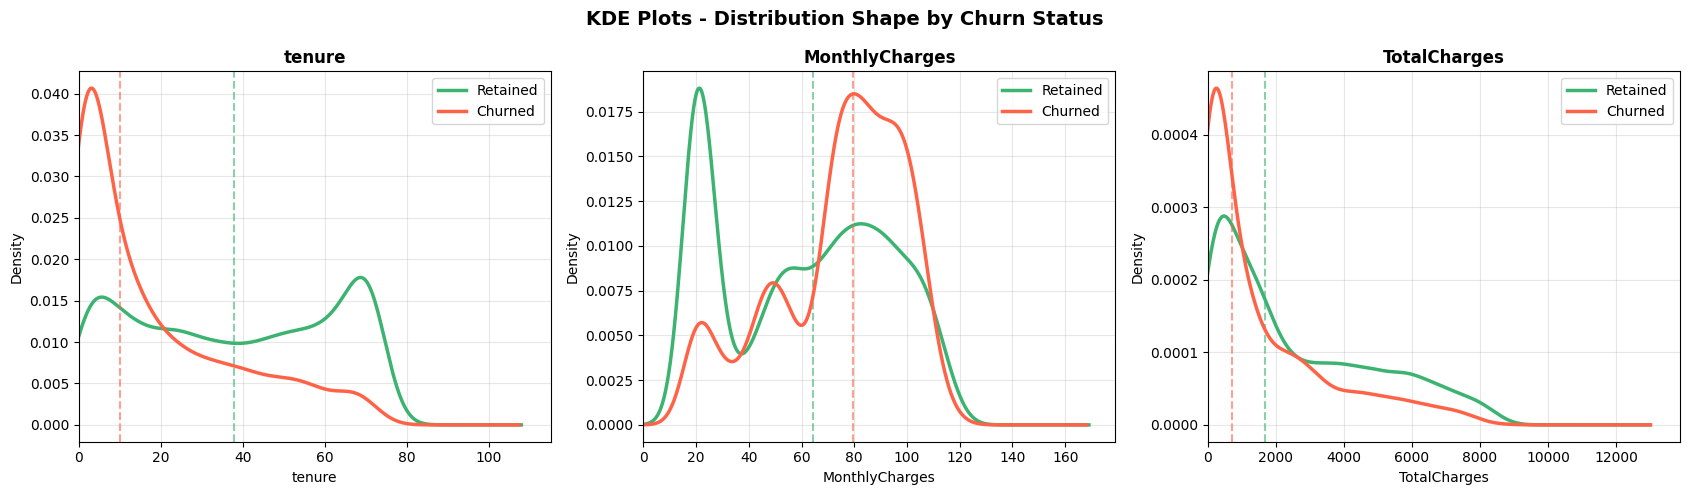

Dashed lines = medians. Separated peaks = the variable distinguishes churners well.


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('KDE Plots - Distribution Shape by Churn Status', fontsize=14, fontweight='bold')

for ax, col in zip(axes, ['tenure', 'MonthlyCharges', 'TotalCharges']):
    for val, label, color in zip([0,1], ['Retained','Churned'], ['mediumseagreen','tomato']):
        data = df[df['Churn']==val][col].dropna()
        data.plot.kde(ax=ax, label=label, color=color, linewidth=2.5)
        ax.axvline(data.median(), color=color, linestyle='--', alpha=0.6, linewidth=1.5)
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Density')
    ax.legend()
    ax.grid(alpha=0.3)
    ax.set_xlim(left=0)

plt.tight_layout()
plt.savefig('viz_07_kde_plots.png', bbox_inches='tight', dpi=120)
plt.show()
print("Dashed lines = medians. Separated peaks = the variable distinguishes churners well.")

## Chart 8: Service Usage vs Churn
A stacked bar chart was created to compare churn distribution across different service combinations.

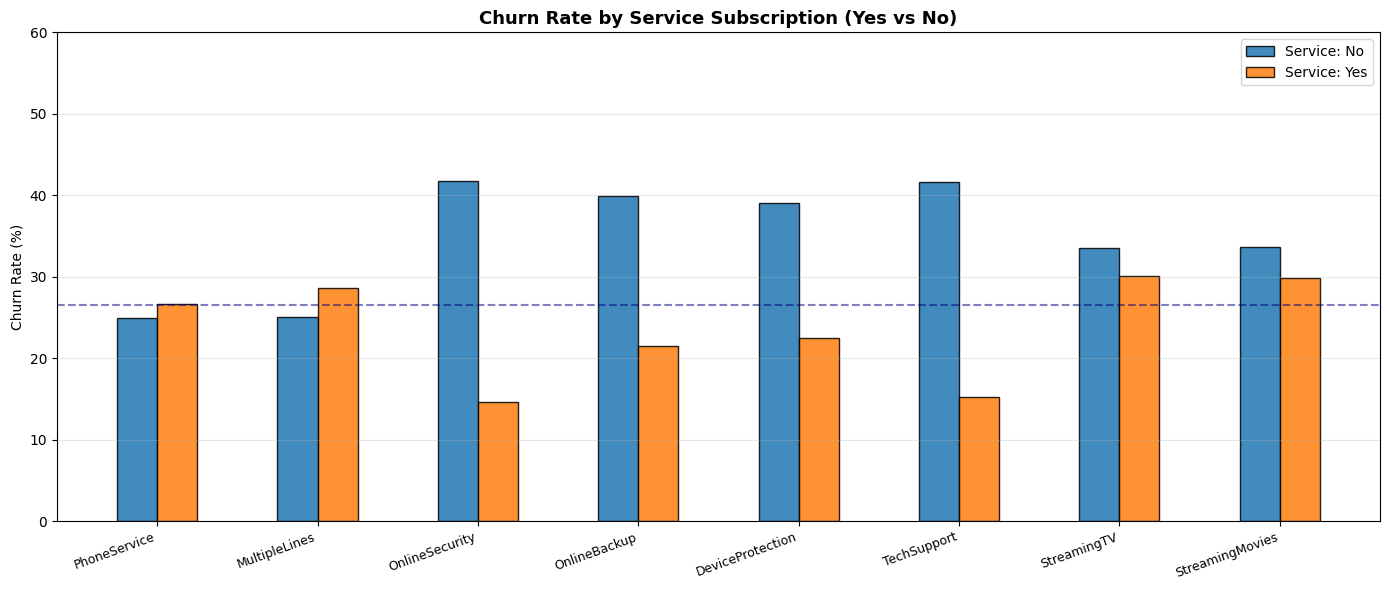

Key insight: Customers WITHOUT OnlineSecurity and TechSupport have significantly higher churn


In [9]:
service_cols = ['PhoneService','MultipleLines','OnlineSecurity','OnlineBackup',
                'DeviceProtection','TechSupport','StreamingTV','StreamingMovies']

churn_by_service = {}
for col in service_cols:
    if col in df.columns:
        rates = df.groupby(col)['Churn'].mean().mul(100).round(1)
        churn_by_service[col] = rates

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(service_cols))
w = 0.25
for i, val in enumerate(['No', 'Yes']):
    heights = []
    for col in service_cols:
        if col in churn_by_service and val in churn_by_service[col].index:
            heights.append(churn_by_service[col][val])
        else:
            heights.append(0)
    bars = ax.bar(x + (i-0.5)*w, heights, w, label=f'Service: {val}',
                  edgecolor='black', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(service_cols, rotation=20, ha='right', fontsize=9)
ax.set_title('Churn Rate by Service Subscription (Yes vs No)', fontsize=13, fontweight='bold')
ax.set_ylabel('Churn Rate (%)')
ax.legend()
ax.axhline(df['Churn'].mean()*100, color='navy', linestyle='--', alpha=0.5, label='Overall avg')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 60)

plt.tight_layout()
plt.savefig('viz_08_service_churn.png', bbox_inches='tight', dpi=120)
plt.show()
print("Key insight: Customers WITHOUT OnlineSecurity and TechSupport have significantly higher churn")

## Chart 9: Scatter Plot - Tenure vs Charges
A scatter plot was generated to examine the relationship between tenure and monthly charges.

Churn status was used to observe distribution patterns across customers.

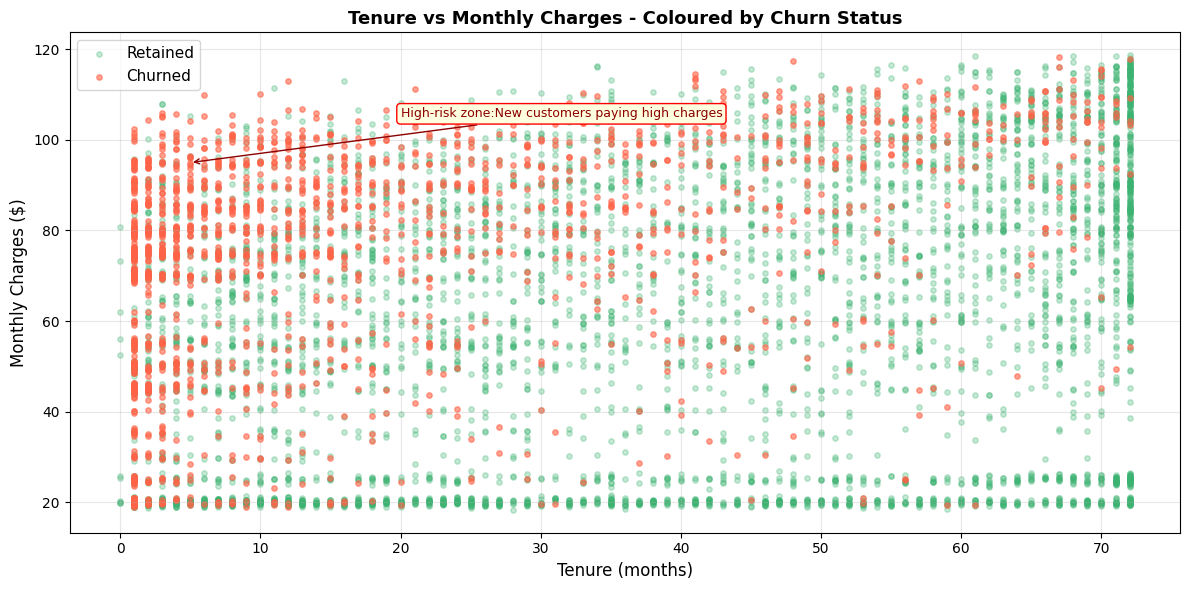


=== Task 6 Complete ===
9 chart types created: box plots, violin plots, grouped violin, pair plot,
correlation heatmap, service heatmap, KDE plots, bar chart, scatter plot


In [10]:
fig, ax = plt.subplots(figsize=(12, 6))

for val, label, color, alpha in [(0,'Retained','mediumseagreen',0.3), (1,'Churned','tomato',0.6)]:
    subset = df[df['Churn']==val]
    ax.scatter(subset['tenure'], subset['MonthlyCharges'],
               c=color, alpha=alpha, s=15, label=label)

ax.set_xlabel('Tenure (months)', fontsize=12)
ax.set_ylabel('Monthly Charges ($)', fontsize=12)
ax.set_title('Tenure vs Monthly Charges - Coloured by Churn Status', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

# annotation for the dangerous zone
ax.annotate('High-risk zone:New customers paying high charges',xy=(5, 95), fontsize=9, color='darkred',bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='red'),arrowprops=dict(arrowstyle='->', color='darkred'),xytext=(20, 105))

plt.tight_layout()
plt.savefig('viz_09_scatter_tenure_charges.png', bbox_inches='tight', dpi=120)
plt.show()

print()
print("=== Task 6 Complete ===")
print("9 chart types created: box plots, violin plots, grouped violin, pair plot,")
print("correlation heatmap, service heatmap, KDE plots, bar chart, scatter plot")